In [ ]:
# Audio Classification using Convolutional Neural Networks (CNN)

# Phase 1: Environment Setup & Dataset Initialization
# In this section, we clone the ESC-50 Environmental Sound Classification dataset, install necessary audio processing dependencies (`librosa`), and 
# configure the PyTorch environment for GPU acceleration.

In [18]:
# --- 1. Dependencies Installation & Dataset Cloning ---
!git clone https://github.com/karolpiczak/ESC-50.git
!pip install -q librosa torch torchvision torchaudio scikit-learn seaborn tqdm

# --- 2. Core Libraries ---
import os
import time
import librosa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

# --- 3. Hardware Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Compute Device: {device}")

fatal: destination path 'ESC-50' already exists and is not an empty directory.
Використовується пристрій: cuda


In [ ]:
# Phase 2: Feature Extraction
# Raw audio waveforms are difficult for standard CNNs to process directly. We transform the audio signals into 2D visual representations using two distinct methods:
# 1. **Mel-Spectrograms:** Represents the frequency spectrum across time, mapped to the human-perceived Mel scale.
# 2. **MFCC (Mel-Frequency Cepstral Coefficients):** A highly compressed representation of the spectral envelope.

In [19]:
# --- 1. Metadata Loading ---
meta_df = pd.read_csv('./ESC-50/meta/esc50.csv')
audio_dir = './ESC-50/audio/'

# --- 2. Extraction Function ---
def extract_audio_features(dataframe, audio_path, sr=22050):
    mel_features = []
    mfcc_features = []
    labels = []
    folds = []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Processing audio files"):
        file_path = os.path.join(audio_path, row['filename'])
        
        # Load exactly 5 seconds of audio
        y, _ = librosa.load(file_path, sr=sr, duration=5)

        # Zero-padding if the audio file is shorter than 5 seconds
        if len(y) < sr * 5:
            y = np.pad(y, (0, sr * 5 - len(y)))

        # 1. Mel-spectrogram (logarithmic scale mapping)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        # Min-Max Normalization (Critical for CNN gradient stability)
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)

        # 2. MFCC Extraction
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc_norm = (mfcc - mfcc.min()) / (mfcc.max() - mfcc.min() + 1e-6)

        mel_features.append(mel_norm)
        mfcc_features.append(mfcc_norm)
        labels.append(row['target'])
        folds.append(row['fold'])

    # Add channel dimension (Channel = 1) required by PyTorch Conv2D layers
    X_mel = np.expand_dims(np.array(mel_features), axis=1)
    X_mfcc = np.expand_dims(np.array(mfcc_features), axis=1)

    return X_mel, X_mfcc, np.array(labels), np.array(folds)

# --- 3. Execution ---
X_mel, X_mfcc, y_labels, folds = extract_audio_features(meta_df, audio_dir)
print(f"Mel-Spectrogram Matrix Shape: {X_mel.shape}")
print(f"MFCC Matrix Shape: {X_mfcc.shape}")

Обробка аудіофайлів:   0%|          | 0/2000 [00:00<?, ?it/s]

Розмірність матриці Mel-спектрограм: (2000, 1, 64, 216)
Розмірність матриці MFCC: (2000, 1, 40, 216)


In [ ]:
# Phase 3: PyTorch Dataset & CNN Architecture
# We define a custom PyTorch Dataset to handle the extracted features. The `AudioCNN` architecture is designed with Batch Normalization for 
# stability and Adaptive Average Pooling to dynamically handle potential input dimension variances.

In [20]:
# --- 1. Custom Dataset Definition ---
class SoundDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# --- 2. CNN Architecture Definition ---
class AudioCNN(nn.Module):
    def __init__(self, num_classes=50):
        super(AudioCNN, self).__init__()
        
        # Convolutional block with Batch Normalization for gradient stabilization
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Adaptive pooling reduces arbitrary spatial dimensions to a fixed output vector
            nn.AdaptiveAvgPool2d((2, 2))
        )
        
        # Fully Connected Classification Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def get_model_param_size(model):
    """Calculates the total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
# Phase 4: Dynamic Training & Evaluation Framework
# This function handles the end-to-end training lifecycle. It respects the dataset's native 5-fold structure (training on folds 1-4, 
# testing on fold 5), integrates a dynamic Learning Rate scheduler, and captures multi-class classification metrics (F1, Accuracy, ROC-AUC).

In [21]:
def run_sound_experiment(X, y, folds, mode_name, epochs=30, batch_size=32):
    # Strict split: Folds 1-4 for Training, Fold 5 for pure Validation/Testing
    train_idx = np.where(folds != 5)[0]
    test_idx = np.where(folds == 5)[0]

    train_loader = DataLoader(SoundDataset(X[train_idx], y[train_idx]), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(SoundDataset(X[test_idx], y[test_idx]), batch_size=batch_size, shuffle=False)

    model = AudioCNN(num_classes=50).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Reduces LR iteratively if validation accuracy plateaus for 3 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_acc': []}

    print(f"\n--- Initiating Training Sequence for Representation: {mode_name} ---")
    start_train_time = time.time()

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        epoch_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs.to(device))
                preds = torch.argmax(outputs, dim=1)
                correct += (preds.cpu() == labels).sum().item()
                total += labels.size(0)

        acc = correct / total
        avg_loss = epoch_loss / len(train_loader)

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(acc)
        scheduler.step(acc)

        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    train_duration = time.time() - start_train_time

    # --- Final Testing & Metrics Aggregation ---
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    start_infer_time = time.time()

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    inference_duration = time.time() - start_infer_time

    # Binarize labels required for Multi-class ROC-AUC calculation
    y_true_bin = label_binarize(all_labels, classes=range(50))

    return {
        'mode': mode_name,
        'model': model,
        'input_shape': X[0].shape,
        'param_size': get_model_param_size(model),
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, average='weighted'),
        'auc': roc_auc_score(y_true_bin, np.array(all_probs), multi_class='ovr', labels=range(50)),
        'cm': confusion_matrix(all_labels, all_preds),
        'history': history,
        'train_time': train_duration,
        'infer_time': inference_duration,
        'y_true': all_labels,
        'y_pred': all_preds
    }

In [ ]:
# Phase 5: Execution & Comparative Analysis
# We train identical network architectures on both the Mel-Spectrogram and MFCC representations to empirically determine which signal 
# processing approach yields superior generalization for environmental sound classification.

In [22]:
# --- 1. Execute Training Experiments ---
results_mel = run_sound_experiment(X_mel, y_labels, folds, mode_name='Mel-Spectrogram')
results_mfcc = run_sound_experiment(X_mfcc, y_labels, folds, mode_name='MFCC')


--- Запуск навчання для представлення: Mel-Spectrogram ---
Епоха 05/30 | Loss: 2.2846 | Val Acc: 0.3225 | LR: 0.001000
Епоха 10/30 | Loss: 1.6626 | Val Acc: 0.4200 | LR: 0.001000
Епоха 15/30 | Loss: 1.2354 | Val Acc: 0.5000 | LR: 0.001000
Епоха 20/30 | Loss: 1.0487 | Val Acc: 0.4850 | LR: 0.001000
Епоха 25/30 | Loss: 0.8591 | Val Acc: 0.5900 | LR: 0.000500
Епоха 30/30 | Loss: 0.7217 | Val Acc: 0.6300 | LR: 0.000250

--- Запуск навчання для представлення: MFCC ---
Епоха 05/30 | Loss: 3.1909 | Val Acc: 0.0875 | LR: 0.001000
Епоха 10/30 | Loss: 2.6603 | Val Acc: 0.2525 | LR: 0.001000
Епоха 15/30 | Loss: 2.2087 | Val Acc: 0.1775 | LR: 0.001000
Епоха 20/30 | Loss: 1.9393 | Val Acc: 0.2775 | LR: 0.000500
Епоха 25/30 | Loss: 1.7437 | Val Acc: 0.3950 | LR: 0.000250
Епоха 30/30 | Loss: 1.7049 | Val Acc: 0.3375 | LR: 0.000250



=== ПОРІВНЯЛЬНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ ===


,Характеристика,Розмір входу,К-сть параметрів,Час навч. (сек),Час інфер. (сек),Accuracy,F1-Score (Weighted),ROC-AUC
0,Mel-Spectrogram,"(1, 64, 216)",237298,32.79,0.08,0.6300,0.6165,0.9748
1,MFCC,"(1, 40, 216)",237298,20.10,0.06,0.3375,0.3188,0.9240


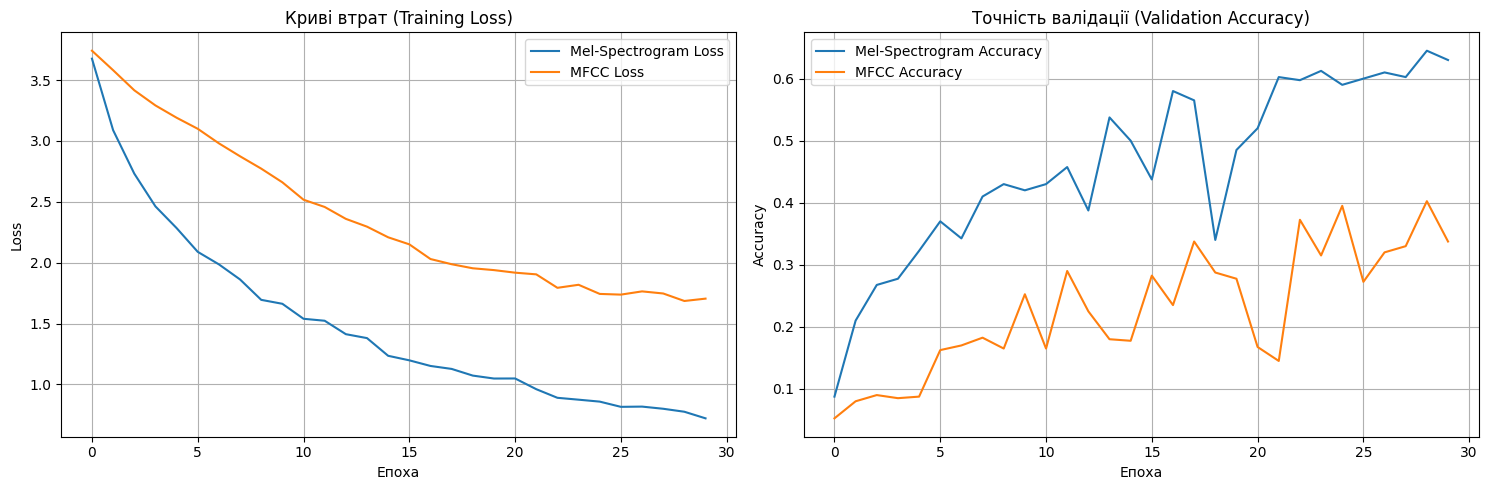

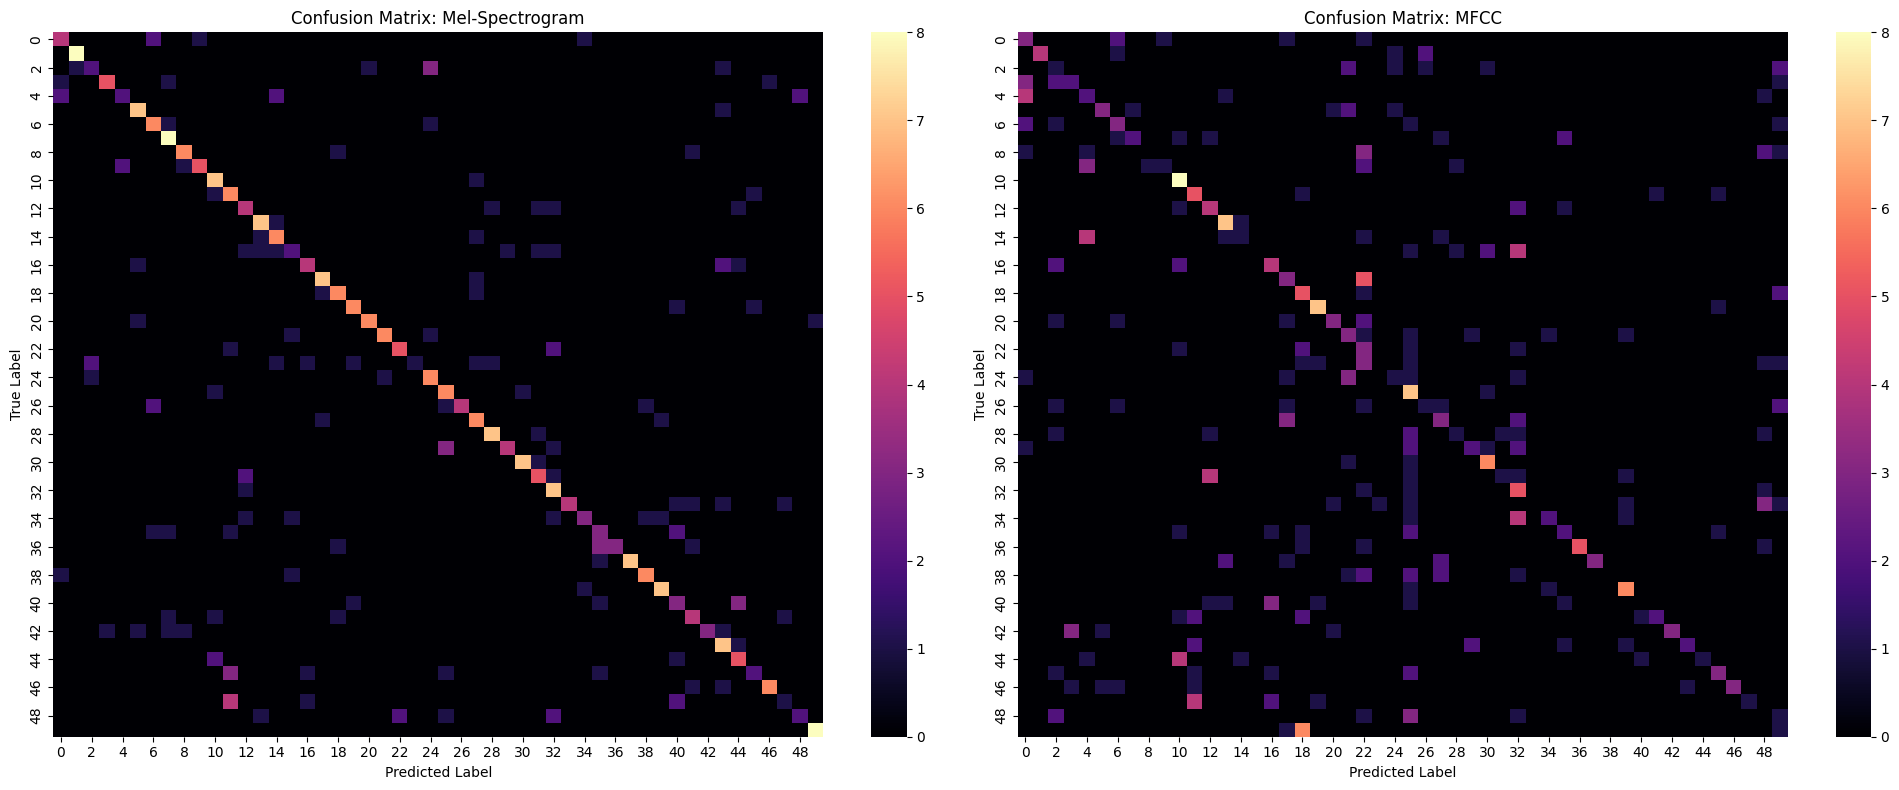

In [23]:
# --- 2. Construct Comparative Data Table ---
all_results = [results_mel, results_mfcc]
summary_data = []

for res in all_results:
    summary_data.append({
        'Feature Type': res['mode'],
        'Input Matrix Shape': str(res['input_shape']),
        'Parameters Count': res['param_size'],
        'Train Time (s)': round(res['train_time'], 2),
        'Inference Time (s)': round(res['infer_time'], 2),
        'Accuracy': round(res['accuracy'], 4),
        'F1-Score (Weighted)': round(res['f1'], 4),
        'ROC-AUC': round(res['auc'], 4)
    })

comparison_df = pd.DataFrame(summary_data)
print("\n=== COMPARATIVE RESULTS OVERVIEW ===")
display(comparison_df)

# Optional: Detailed Class-by-Class Classification Report
# for res in all_results:
#     print(f"\n--- Detailed Classification Report for: {res['mode']} ---")
#     print(classification_report(res['y_true'], res['y_pred'], zero_division=0))

# --- 3. Visualize Learning Curves ---
plt.figure(figsize=(15, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
for res in all_results:
    plt.plot(res['history']['train_loss'], label=f"{res['mode']} Loss")
plt.title('Training Loss Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss Function')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
for res in all_results:
    plt.plot(res['history']['val_acc'], label=f"{res['mode']} Accuracy")
plt.title('Validation Accuracy Progression')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 4. Render Confusion Matrices ---
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
for i, res in enumerate(all_results):
    sns.heatmap(res['cm'], ax=ax[i], cmap='magma', annot=False)
    ax[i].set_title(f"Confusion Matrix: {res['mode']}")
    ax[i].set_xlabel('Predicted Class Label')
    ax[i].set_ylabel('True Class Label')
plt.tight_layout()
plt.show()

In [ ]:
# Phase 6: Model Interpretability (Audio Grad-CAM)
# To verify that the model is learning meaningful temporal-frequency patterns rather than dataset noise, 
# we apply Gradient-weighted Class Activation Mapping (Grad-CAM) to the final convolutional layer. 
# This heatmap reveals the exact frequencies and time signatures that triggered the CNN's classification decision.

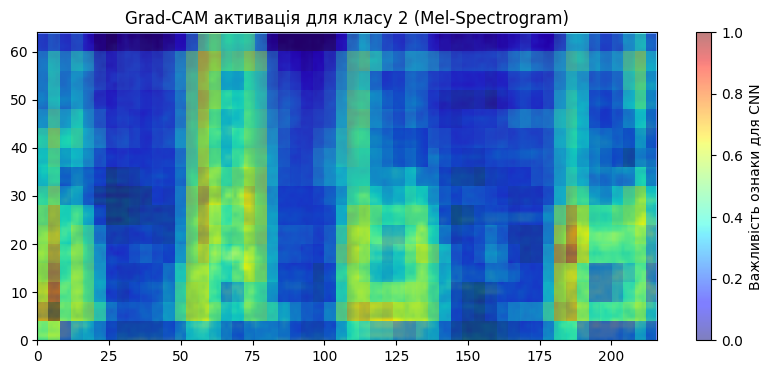

In [24]:
import torch.nn.functional as F

def generate_gradcam(model, input_tensor, target_class):
    """Calculates Grad-CAM activation map for a given input tensor."""
    model.eval()

    gradients = []
    activations = []

    def save_gradient(grad):
        gradients.append(grad)

    # Register hooks on the target convolutional layer
    target_layer = model.features[10]
    hook_handle = target_layer.register_forward_hook(lambda m, i, o: activations.append(o))

    # Forward Pass
    output = model(input_tensor.unsqueeze(0).to(device))
    hook_handle.remove()

    # Backward Pass to compute gradients
    loss = output[0, target_class]
    target_layer.weight.register_hook(lambda grad: save_gradient(grad))
    loss.backward()

    # Formulate heatmap projection
    act = activations[0].detach().cpu().numpy()[0]
    heatmap = np.mean(act, axis=0)
    heatmap = np.maximum(heatmap, 0) # Discard negative values (ReLU behavior)

    # Normalize heatmap intensity [0, 1]
    if np.max(heatmap) == 0:
        heatmap /= 1e-8
    else:
        heatmap /= np.max(heatmap) 

    return heatmap

# --- Grad-CAM Execution ---
# Select the first sample from the pure test fold
test_idx_0 = np.where(folds == 5)[0][0]
sample_input = torch.tensor(X_mel[test_idx_0], dtype=torch.float32)
true_label = y_labels[test_idx_0]

# Generate Interpretability Heatmap
heatmap = generate_gradcam(results_mel['model'], sample_input, true_label)

# Extract original dimensions for proper overlay scaling
_, h, w = sample_input.shape

plt.figure(figsize=(10, 4))

# 1. Plot Base Spectrogram
plt.imshow(sample_input[0].numpy(), cmap='viridis', aspect='auto', origin='lower')

# 2. Overlay Grad-CAM Heatmap
plt.imshow(heatmap, cmap='jet', alpha=0.5, aspect='auto', origin='lower', extent=[0, w, 0, h])

plt.title(f"Grad-CAM Activation for Class {true_label} (Mel-Spectrogram)")
plt.colorbar(label='CNN Feature Importance')
plt.show()